In [24]:
#SHAP intro:
#1. application to california housing dataset (regression problem)
#2. short discussion about differences between applying shap for regression and classification
#3. how to use adult income dataset in this task

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, make_classification
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
SEED = 42

In [3]:
#1. application to california housing dataset (regression problem)
#1.1 load and split the data
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
feature_names = housing.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [4]:
#1.2 train a random forest for regression
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [5]:
#1.3 initialize JS visualization (might be required for some shap plots in notebooks)
shap.initjs()

In [6]:
#1.4 create the SHAP explainer, calculate SHAP values for test set
explainer = shap.TreeExplainer(rf)

X_shap = X_test.iloc[:100] #for speed, we use a subsample of test set (this may take a while..)
shap_values = explainer.shap_values(X_shap)

In [7]:
print(f"SHAP values shape: {shap_values.shape}")
print(f"  (samples × features = {X_shap.shape[0]} × {X_shap.shape[1]})")
print()

SHAP values shape: (100, 8)
  (samples × features = 100 × 8)



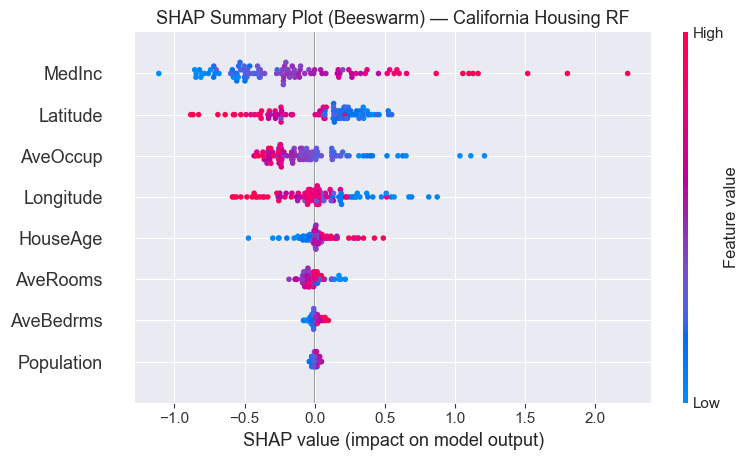

In [8]:
#1.5 summary plot: beeswarm
#each dot = one sample, position = SHAP value, color = feature value
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot (Beeswarm) — California Housing RF', fontsize=13)
plt.tight_layout()
plt.show()

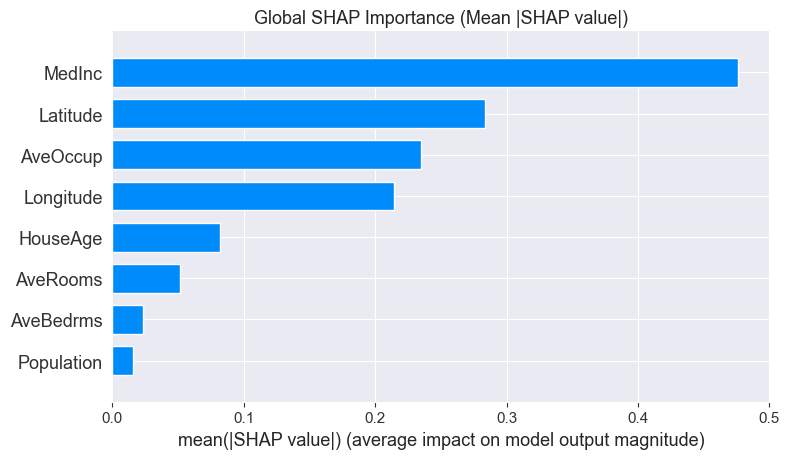

In [9]:
#1.6 bar plot of global mean |SHAP|
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Global SHAP Importance (Mean |SHAP value|)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
#1.7 let's pick one high-value prediction, one low-value prediction, one average-value prediction
preds = rf.predict(X_shap)
idx_high = np.argmax(preds)
idx_low  = np.argmin(preds)
idx_mid = np.argmin(np.abs(preds - np.mean(preds)))

In [11]:
#1.8 force plots for each selected instance
shap.plots.force(explainer.expected_value, shap_values[idx_high], X_shap.iloc[idx_high,:])

In [12]:
shap.plots.force(explainer.expected_value, shap_values[idx_low], X_shap.iloc[idx_low, :])

In [13]:
shap.plots.force(explainer.expected_value, shap_values[idx_mid], X_shap.iloc[idx_mid, :])

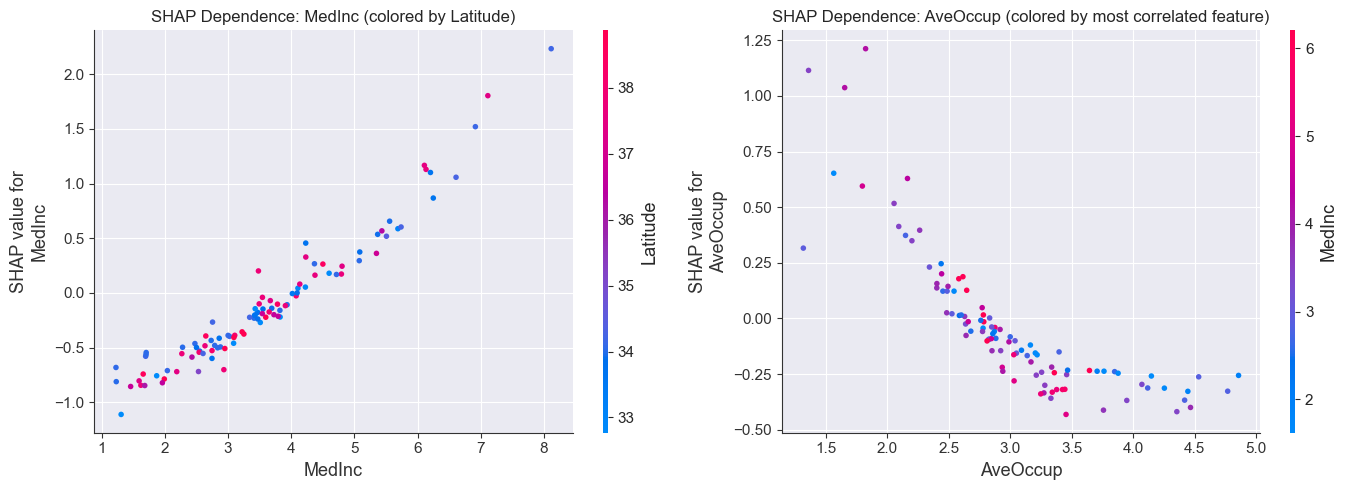

In [14]:
#1.9 SHAP dependence plot
# Color = interaction feature (automatically selected as most correlated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    'MedInc', shap_values, X_shap,
    feature_names=list(feature_names),
    interaction_index='Latitude',
    ax=axes[0], show=False
)
axes[0].set_title('SHAP Dependence: MedInc (colored by Latitude)')

shap.dependence_plot(
    'AveOccup', shap_values, X_shap,
    feature_names=list(feature_names),
    ax=axes[1], show=False
)
axes[1].set_title('SHAP Dependence: AveOccup (colored by most correlated feature)')

plt.tight_layout()
plt.show()

In [15]:
#2. short discussion about differences between applying shap for regression and classification
#2.1 let's make a quick artificial example for classification
X_clf, y_clf = make_classification(n_samples=500, n_features=8, random_state=SEED)

clf = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf.fit(X_clf, y_clf)

explainer_clf = shap.TreeExplainer(clf)

#watch out: here we calculate shap values for training set (which we shouldn't do), but it is only for inspecting the shape of the output
shap_values_clf = explainer_clf.shap_values(X_clf)

In [16]:
#2.2 inspect the difference in shapes of shap values
print("--- Regression (California Housing) ---")
# Result is a single array of shape (samples, features)
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Expected value (Base value): {explainer.expected_value}")
print("\n--- Classification (Artificial Dataset) ---")
# for classification, TreeExplainer (in recent versions) returns a 3D array: (samples, features, classes)
print(f"SHAP values shape: {np.array(shap_values_clf).shape}")
print(f"SHAP values shape (for Class 1): {shap_values_clf[:,:,1].shape}")
print(f"Expected values (Base values for both classes): {explainer_clf.expected_value}")
print(f"Expected value (Base value for Class 1): {explainer_clf.expected_value[1]}")

--- Regression (California Housing) ---
SHAP values shape: (100, 8)
Expected value (Base value): [2.07293585]

--- Classification (Artificial Dataset) ---
SHAP values shape: (500, 8, 2)
SHAP values shape (for Class 1): (500, 8)
Expected values (Base values for both classes): [0.4988 0.5012]
Expected value (Base value for Class 1): 0.5012000000000001


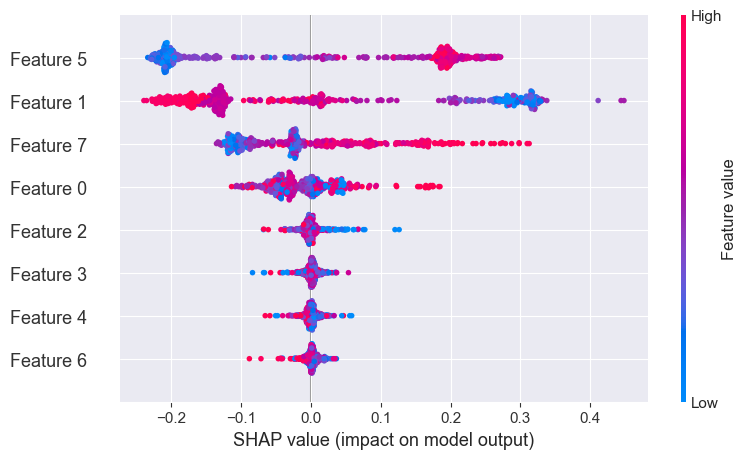

In [17]:
#2.3 quick example of shap for classification (to show the syntax, we don't care about the results here): summary plot
sv_class1 = shap_values_clf[:,:,1]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_class1, X_clf,
    show=False
)

In [18]:
#2.4 quick example of shap for classification: force plot
base_value_clf = explainer_clf.expected_value[1]

# let's pick the instance with the highest probability for Class 1
probs = clf.predict_proba(X_clf)[:, 1]
idx_clf = np.argmax(probs)

shap.plots.force(base_value_clf, sv_class1[idx_clf], X_clf[idx_clf,:])

In [19]:
#3. how to use adult income dataset in this task
#3.1 we load data in two versions: X_encoded (for model fitting) and X_raw (for human-readable plots); y is the same
X_encoded, y = shap.datasets.adult()
X_raw, _ = shap.datasets.adult(display=True)

In [20]:
#3.2 quick look at the difference between X_encoded and X_raw
X_encoded.head()

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5


In [21]:
X_raw.head()

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


In [22]:
#3.3 we must split both datasets using the same random_state
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=SEED
)
_, X_test_display, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED
)

In [23]:
#3.4 what should come next
# - training the model using X_train, y_train
# - calculating shap values using X_test (remember: this is a classification problem!)
# - in shap plots use X_test_display as argument
# - if working with subsample from X_test - make the same subsample from X_test_display